In [1]:
%pip install --upgrade pip
%pip install spotipy opencv-python tensorflow numpy

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import matplotlib.pyplot as plt
import os


In [4]:
import tensorflow as tf
import cv2
import spotipy
import numpy as np

print("TensorFlow version:", tf.__version__)
print("OpenCV version:", cv2.__version__)
print("All libraries loaded successfully!")

TensorFlow version: 2.20.0
OpenCV version: 4.13.0
All libraries loaded successfully!


In [8]:
import zipfile

with zipfile.ZipFile('Emotion.zip', 'r') as zip_ref:
    zip_ref.extractall()

import os
print("Current Folder:", os.listdir())

train_dir = 'train/'
test_dir = 'test/'
print(os.listdir('train'))
print(os.listdir('test'))



Current Folder: ['.arduinoIDE', '.eclipse', '.idlerc', '.ipynb_checkpoints', '.ipython', '.jupyter', '.keras', '.matplotlib', '.p2', '.vscode', '24i144', '717824i144_certificates', 'Adobe_Photoshop_2021_v22.5.1.441x64', 'AI vs job.ipynb', 'ai_job_trends_dataset.csv', 'AppData', 'Application Data', 'bluetooth.html', 'Contacts', 'Cookies', 'cybersecurity_large_synthesized_data[1].csv', 'Data1.csv', 'Documents', 'Downloads', 'Dropbox', 'eclipse', 'Education_dataset.csv', 'EDUCATION_SOT.ipynb', 'Emotion .ipynb', 'Emotion.zip', 'Employee.class', 'Entertainment_dataset.csv', 'Favorites', 'Finance_dataset.csv', 'geeksforgeeks.pdf', "gokul's work.ipynb", 'googleplaystore.csv', 'Health_dataset.csv', 'i106', 'i144', 'index.html', 'IndianEmployee.class', 'Indian_Climate_Dataset_2024_2025 (1).csv', 'IT_dataset.csv', 'Java', 'jupyter', 'l1', 'l106', 'l111', 'l134', 'l144', 'l155', 'lab1.ipynb', 'Links', 'Local Settings', 'Main.class', 'Main.java', 'Manufacture_dataset.csv', 'map.html', 'MLT data.cs

In [9]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Step 1: Define the paths to your Kaggle folders
# Replace these with the actual folder names on your computer
train_dir = 'train/' 
test_dir = 'test/'

# Step 2: Initialize the Generators
# 'rescale' converts pixel values from 0-255 to 0-1 for faster learning
train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,  # Augmentation: helps AI see faces from different angles
    rotation_range=10      # Slightly rotate images to make the AI more "robust"
)

test_datagen = ImageDataGenerator(rescale=1./255)

# Step 3: Load the images from your folders
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(48, 48),    # FER-2013 standard size
    batch_size=64,
    color_mode="grayscale",  # Essential because FER-2013 is black and white
    class_mode='categorical' # Since we have 7 different emotions
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(48, 48),
    batch_size=64,
    color_mode="grayscale",
    class_mode='categorical'
)

# Step 4: Verify the classes
print("Detected Emotions:", train_generator.class_indices)

Found 28709 images belonging to 7 classes.
Found 3589 images belonging to 7 classes.
Detected Emotions: {'Angry': 0, 'Disgust': 1, 'Fear': 2, 'Happy': 3, 'Neutral': 4, 'Sad': 5, 'Surprise': 6}


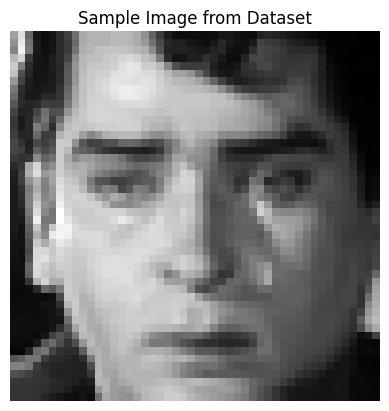

In [10]:
import matplotlib.pyplot as plt

# Grab a batch of images
x, y = next(train_generator)

# Show the first image in the batch
plt.imshow(x[0].reshape(48, 48), cmap='gray')
plt.title("Sample Image from Dataset")
plt.axis('off')
plt.show()

Found 28709 images belonging to 7 classes.
Found 3589 images belonging to 7 classes.
Detected Emotions: {'Angry': 0, 'Disgust': 1, 'Fear': 2, 'Happy': 3, 'Neutral': 4, 'Sad': 5, 'Surprise': 6}


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 46, 46, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 46, 46, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 23, 23, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 21, 21, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 21, 21, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 10, 10, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 8, 8, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 8, 8, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 4, 4, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         262,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 7)                   │             903 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 356,743 (1.36 MB)

 Trainable params: 356,295 (1.36 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/30
448/448 ━━━━━━━━━━━━━━━━━━━━ 75s 160ms/step - accuracy: 0.3055 - loss: 1.7547 - val_accuracy: 0.3638 - val_loss: 1.6067
Epoch 2/30
  1/448 ━━━━━━━━━━━━━━━━━━━━ 44s 99ms/step - accuracy: 0.2969 - loss: 1.7884

C:\Users\Nivetha Natarajan\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


448/448 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.2969 - loss: 1.7884 - val_accuracy: 0.3666 - val_loss: 1.6048
Epoch 3/30
448/448 ━━━━━━━━━━━━━━━━━━━━ 59s 131ms/step - accuracy: 0.3835 - loss: 1.5694 - val_accuracy: 0.4213 - val_loss: 1.4777
Epoch 4/30
448/448 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3438 - loss: 1.5974 - val_accuracy: 0.4277 - val_loss: 1.4727
Epoch 5/30
448/448 ━━━━━━━━━━━━━━━━━━━━ 61s 136ms/step - accuracy: 0.4226 - loss: 1.4843 - val_accuracy: 0.4715 - val_loss: 1.3900
Epoch 6/30
448/448 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4375 - loss: 1.5343 - val_accuracy: 0.4729 - val_loss: 1.3777
Epoch 7/30
448/448 ━━━━━━━━━━━━━━━━━━━━ 64s 143ms/step - accuracy: 0.4511 - loss: 1.4242 - val_accuracy: 0.4453 - val_loss: 1.4105
Epoch 8/30
448/448 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4219 - loss: 1.4693 - val_accuracy: 0.4378 - val_loss: 1.4307
Epoch 9/30
448/448 ━━━━━━━━━━━━━━━━━━━━ 59s 131ms/step - accuracy: 0.4696 - loss: 1.3845 - val_accuracy: 0

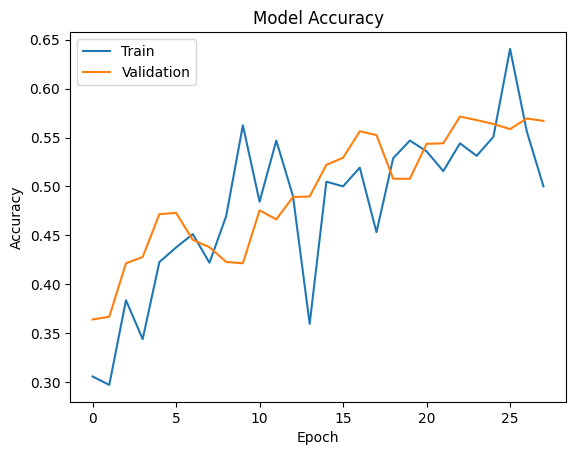

In [2]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

plt.show()
